## 2D Orzag-Tang vortex evolution

The Orzag-Tang vortex is a classic 2D problem used to test plasma physics codes. It starts with a simple, smooth layout of fluid flow vortices and magnetic fields. As time progresses in the simulation, these fields interact violently, generating complex turbulence and magnetic reconnection. You will watch these smooth initial conditions break down into beautiful complex patterns, before settling into a relatively steady set of vortices.

In this example we simulate a modified Orzag-Tang vortex (given in *Loureiro et al. 2016, Comput. Phys. Commun. 206 (2016): 45-63*):

$\Phi = \cos(x+1.4) + \cos(y + 0.5), \quad \Psi = \cos(2x+2.3)+\cos(y+4.1)$

In [1]:
#This just imports the stuff we will need to run the simulation

#main package: it imports some basic stuff as standard that is necessary to run a simulation.
#(look in jax_rmhd/__init__.py if you want to see what exactly is imported by default)
import jax_rmhd as jr
#jax version of numpy: this is recommended over the usual numpy to work with the just-in-time compilation, etc
import jax.numpy as jnp
# this imports all the Fourier transforms we will need
import jax.numpy.fft as ft
# plotting stuff
import matplotlib.pyplot as plt
#utilities
import os

#specifically importing stuff for snapshots and simple diagnostics
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag

#Q2: What do you think this function does specifically? Find it in the jax_rmhd folder, or create a new
#cell and run ??jr.init_cluster to read the code directly here.
jr.init_cluster()

jax is using 64bit precision.


In [2]:
#this just sets some parameters for the simulation
#Q3: Add comments saying what they do (as many as you can, we can discuss the rest!)
nx = 256
ny = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap=0.1
t_end=10.0
cfl_safety=1.0
spatial_dimensions=2
snap_path="data/orzag-tang-2D/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3


#This is setting up the grids for the simulation. They are only used for initialization with a known function
x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#set up orbax snapshot manager: this is needed for the machinery for taking snapshots of the code outputs.
#You can find the function in snapshot_io.py. It is imported by default since it is almost always needed
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
#First, the parameters object: This is a static object that contains EVERY parameter in the problem.
#You can find the code in config.py
params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
#kgrid contains the kx,ky grids necessary for the problem. You can find the code in fourier.py
kgrid = jr.setup_kgrids(params)

#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
def test_init(x,y):
    phi = (jnp.cos(x+1.4) + jnp.cos(y+0.5))
    psi = (jnp.cos(2.0*x+2.3) + jnp.cos(y + 4.1))
    return jnp.stack([phi,psi],axis=0)
#Note that phi is the STREAM FUNCTION that is related to the perpendicular velocity, u_perp = hz x grad_perp (phi)
#psi is the FLUX FUNCTION that is related to the perpendicular magnetic field b_perp = hz x grad_perp (psi)
#"perpendicular" here means perpendicular to the (very strong) background magnetic field, which points in the z direction.
# grad_perp =(∂/∂x,∂/∂y,0)
# hz = (0,0,1) the unit vector in the z direction
#Since this is a 2D simulation, note that nz=1.
#In components, this means that u_x = - ∂phi/∂y, u_y = ∂phi/∂x
#Q4: Try to apply the perpendicular divergence (grad_perp . )to the definitions of u_perp and b_perp above. What do you get?

#This function takes another function (in this case, test_init) and sets up the simulation state
#It looks a bit cumbersome, but this is necessary because on a cluster, each core will own a
#different part of the whole array. This function sets this smoothly.
#Q5: Look for the initialize function in run.py. Can you describe what it does?
#The SimulationState object is defined in types.py. It holds the current time (t=0 at the start) and all
#of the fluctuating fields in the problem (in this case, there are 2: phi and psi).
#Note the the fields are stored as their Fourier transform: instead of storing them as a function of x,y,
#we store them as a function of kx,ky.
#Q6: Why do you think this is? Look up "fourier transform of a derivative" and read a bit. The Fourier transform is really useful
#for solving differential equations, because we can transform derivatives into multiplication by ik: this transforms differential 
#equations into algebraic ones, which are generally much easier to solve!
#Q7: What is the shape of the fields array with these parameters?
state=jr.initialize(test_init,params)

#This is just a helper function to estimate how many timesteps should be taken before exiting to see if we want to take a snapshot
nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock))

nblock estimate: 11


In [3]:
#do the simulation
#Q8 (optional): This is doing quite a lot. If you like, you could sketch out a block diagram of what functions are called inside here.
end_state=jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,save=True)

Saving initial state as snapshot 0
0.09313738459826092
0.1848661503898373
Saving snapshot 1
0.2750275096798465
0.36304113913048486
Saving snapshot 2
0.44837294402210726
0.5306044772904323
Saving snapshot 3
0.6094632377416049
0.6848435100493336
Saving snapshot 4
0.7568229645421691
0.8256539791899308
Saving snapshot 5
0.8917136339207148
0.9548120651091815
Saving snapshot 6
1.0149733521375905
1.0727899919570378
Saving snapshot 7
1.1288918006138098
1.1837684205336247
Saving snapshot 8
1.237764061101238
1.2911290086474647
Saving snapshot 9
1.3440952376971944
1.3968634222072764
Saving snapshot 10
1.4496439894792195
1.5026576451570062
Saving snapshot 11
1.5561414326982193
1.6099924729410615
Saving snapshot 12
1.6636586033088558
1.7172409756264766
Saving snapshot 13
1.7711620174765053
1.8256792458434798
Saving snapshot 14
1.8800541449633592
1.9343500778374834
Saving snapshot 15
1.9885104704330212
2.0416507293627295
Saving snapshot 16
2.0938802381865993
2.145955108777614
Saving snapshot 17
2.19

In [4]:
#Making some snapshot images. This saves them to snap_path: you can take a look there.
#You should see many images in order of time. You can scan through them to see what happens to the plasma
#as a function of time.
#The VORTICITY (vort) is defined as grad_perp x u_perp.
#In components, this is ∂u_y/∂x - ∂u_x/∂y
#Here you can see I have written this as 
    # inverse fourier transform {- k^2 *  phi_k }
#where phi_k = snap.fields[0,0,:,:]
#Q9: Check this agrees with the definitions (stream function and vorticity) in this notebook.
for isnap in range(0,86):
    snap=sn.load_snapshot(isnap,mngr,params)
    vort=ft.irfft2(-kgrid.ksq()*snap.fields[0,0,:,:])
    plt.imshow(vort,vmin=-50,vmax=50,cmap="afmhot")
    plt.colorbar()
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')

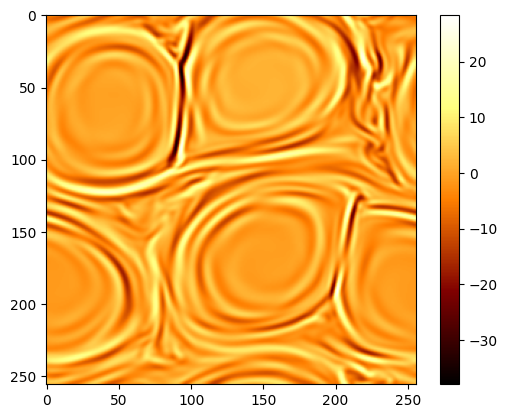

In [5]:
#Just plotting one so we can see it here. 
#Q10: You could also modify this to plot just phi, psi, or components of u_perp or b_perp.
vort=ft.irfft2(-kgrid.ksq()*end_state.fields[0][0,:,:])
plt.imshow(vort,cmap="afmhot")
plt.colorbar()

Text(0, 0.5, '$E(k)$')

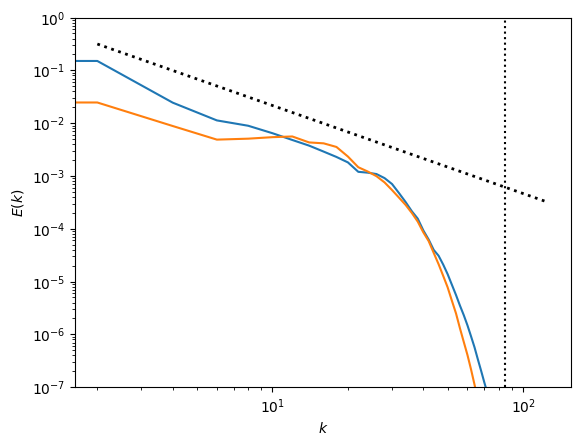

In [8]:
#plot the energy spectrum
#Q11: Based on what we have talked about, what is this doing? Can you describe what the different lines on the plot are? What happens
#if you choose isnap=0?
isnap=50
snap=sn.load_snapshot(isnap,mngr,params)
k=jnp.array(range(0,params.nx//2,2)) # bin_factor in the spec routine is set to 2 by default
bins,su,sb=diag.perpspec(snap,kgrid,params)
plt.loglog(k,sb)
plt.loglog(k,su)
plt.ylim(1e-7,1)
plt.loglog(k,k**(-5.0/3.0),'k:',linewidth=2)
plt.loglog([params.nx//3,params.nx//3],[1e-7,1],'k:')
plt.xlabel(r'$k$')
plt.ylabel(r'$E(k)$')

In [7]:
#This makes a gif of the snapshot images if you have imagemagick installed
os.system("cd " + snap_path + ";"
          + "magick -delay 1 -loop 0 *.png orzag-tang-2D.gif;"
         + "cd ../../")

0

Other things to mess with if you want to:
- Experiment with different dissipation parameters `visc`,`res`,`hyper`. What happens if you make them too small (or zero)?
- Change `nx`, `ny`: how does the total time taken change? How does the spectrum change?
- Try answering some of the questions in the comments to check your understanding.

Once you finish this notebook, you basically understand how to run 2D simulations! The real world is three-dimensional; but there are many interesting problems which are approximately 2D.